In [ ]:
%pip install numpy pandas matplotlib
%pip install seaborn scikit-learn
%pip install kagglehub
%pip install tensorflow

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 3.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.3 MB 7.1 MB/s eta 0:00:02
   ---

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Flatten, Dense, Dropout,
    Conv2D, MaxPooling2D, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.2.6


In [1]:
import kagglehub
import shutil
import os

# Descarga el dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Define la carpeta local donde quieres guardar las imágenes
destino = "chest_xray_dataset"
os.makedirs(destino, exist_ok=True)

# Copia todo el contenido del dataset a tu carpeta local
for item in os.listdir(path):
    source = os.path.join(path, item)
    dest = os.path.join(destino, item)
    
    if os.path.isdir(source):
        # Si es una carpeta, cópiala recursivamente
        shutil.copytree(source, dest, dirs_exist_ok=True)
    else:
        # Si es un archivo, cópialo directamente
        shutil.copy2(source, dest)

print("Dataset copiado a:", os.path.abspath(destino))

# Opcional: muestra la estructura de carpetas
print("\nEstructura del dataset:")
for root, dirs, files in os.walk(destino):
    level = root.replace(destino, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for dir_name in dirs:
        print(f'{subindent}{dir_name}/')

c:\Users\ignac\OneDrive\Documentos\Universidad\TDSE\Tarea-3_TDSE\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.29G/2.29G [24:37<00:00, 1.67MB/s]

Extracting files...


Dataset copiado a: c:\Users\ignac\OneDrive\Documentos\Universidad\TDSE\Tarea-3_TDSE\chest_xray_dataset

Estructura del dataset:
chest_xray_dataset/
  chest_xray/
  chest_xray/
    chest_xray/
    test/
    train/
    val/
    __MACOSX/
    chest_xray/
      test/
      train/
      val/
      test/
        NORMAL/
        PNEUMONIA/
        NORMAL/
        PNEUMONIA/
      train/
        NORMAL/
        PNEUMONIA/
        NORMAL/
        PNEUMONIA/
      val/
        NORMAL/
        PNEUMONIA/
        NORMAL/
        PNEUMONIA/
    test/
      NORMAL/
      PNEUMONIA/
      NORMAL/
      PNEUMONIA/
    train/
      NORMAL/
      PNEUMONIA/
      NORMAL/
      PNEUMONIA/
    val/
      NORMAL/
      PNEUMONIA/
      NORMAL/
      PNEUMONIA/
    __MACOSX/
      chest_xray/
      chest_xray/
        test/
        train/
        val/
        test/
          NORMAL/
          PNEUMONIA/
          NORMAL/
          PNEUMONIA/
        train/
          NORMAL/
          PNEUMONIA/
          NO

---
## 1. Exploración del Dataset (EDA)

El dataset está organizado en tres particiones: `train`, `val` y `test`, cada una con dos subcarpetas: `NORMAL` y `PNEUMONIA`.  
El objetivo es entender la estructura antes de entrenar cualquier modelo.


In [2]:
# Ruta base del dataset (ajustar si es necesario)
BASE_DIR = os.path.join("chest_xray_dataset", "chest_xray")

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

def contar_imagenes(directorio):
    conteo = {}
    total = 0
    for clase in sorted(os.listdir(directorio)):
        ruta_clase = os.path.join(directorio, clase)
        if os.path.isdir(ruta_clase):
            n = len([f for f in os.listdir(ruta_clase)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            conteo[clase] = n
            total += n
    conteo['TOTAL'] = total
    return conteo

train_counts = contar_imagenes(TRAIN_DIR)
val_counts   = contar_imagenes(VAL_DIR)
test_counts  = contar_imagenes(TEST_DIR)

print("Distribucion de clases")
print(f"{'Conjunto':<12} {'NORMAL':>10} {'PNEUMONIA':>12} {'TOTAL':>8}")
print("-" * 46)
print(f"{'Train':<12} {train_counts['NORMAL']:>10} {train_counts['PNEUMONIA']:>12} {train_counts['TOTAL']:>8}")
print(f"{'Val':<12} {val_counts['NORMAL']:>10} {val_counts['PNEUMONIA']:>12} {val_counts['TOTAL']:>8}")
print(f"{'Test':<12} {test_counts['NORMAL']:>10} {test_counts['PNEUMONIA']:>12} {test_counts['TOTAL']:>8}")

Distribucion de clases
Conjunto         NORMAL    PNEUMONIA    TOTAL
----------------------------------------------
Train              1341         3875     5216
Val                   8            8       16
Test                234          390      624


### 1.1 Distribución de clases

El dataset presenta un desbalance de clases: las imágenes de neumonía superan considerablemente
a las normales, especialmente en el conjunto de entrenamiento. Esto es relevante porque
un modelo ingenuo podría aprender a predecir siempre "neumonía" y obtener alta accuracy por defecto.


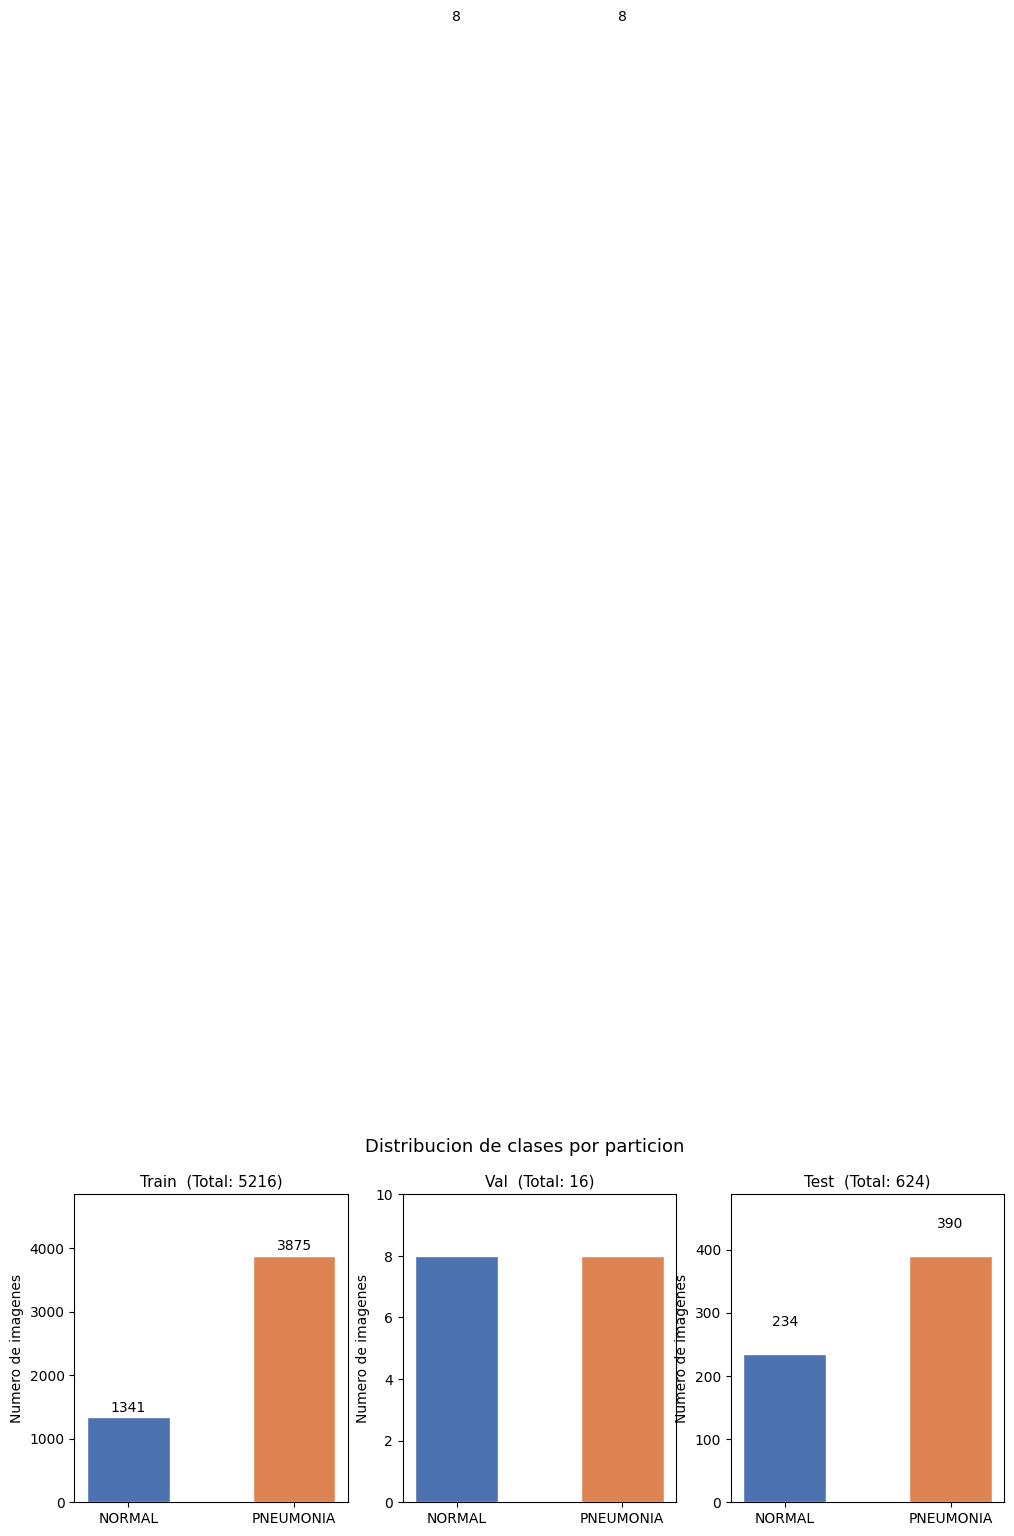

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
conjuntos = [
    ("Train", train_counts),
    ("Val",   val_counts),
    ("Test",  test_counts)
]

for ax, (nombre, counts) in zip(axes, conjuntos):
    clases  = ['NORMAL', 'PNEUMONIA']
    valores = [counts['NORMAL'], counts['PNEUMONIA']]
    colores = ['#4C72B0', '#DD8452']
    bars = ax.bar(clases, valores, color=colores, edgecolor='white', width=0.5)
    ax.set_title(f"{nombre}  (Total: {counts['TOTAL']})", fontsize=11)
    ax.set_ylabel("Numero de imagenes")
    ax.set_ylim(0, max(valores) * 1.25)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                str(val), ha='center', va='bottom', fontsize=10)

plt.suptitle("Distribucion de clases por particion", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("eda_distribucion.png", bbox_inches='tight', dpi=100)
plt.show()


### 1.2 Dimensiones e inspección de imágenes

Las imágenes del dataset son radiografías de tórax en escala de grises,
pero están almacenadas como archivos JPEG que los decodificadores cargan en 3 canales RGB.  
Para este trabajo se redimensionarán a **150 × 150 píxeles** — tamaño suficientemente
representativo que mantiene el tiempo de entrenamiento manejable sin GPU dedicada.


In [6]:
from PIL import Image

def muestrear_dimensiones(directorio, clase, n=30):
    ruta = os.path.join(directorio, clase)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:n]
    dims = []
    for f in archivos:
        with Image.open(os.path.join(ruta, f)) as img:
            dims.append(img.size)   # (ancho, alto)
    anchos  = [d[0] for d in dims]
    altos   = [d[1] for d in dims]
    return anchos, altos

print("Muestra de dimensiones originales (30 imagenes de train/NORMAL):")
anchos, altos = muestrear_dimensiones(TRAIN_DIR, 'NORMAL')
print(f"  Ancho  -> min={min(anchos)}, max={max(anchos)}, media={int(np.mean(anchos))}")
print(f"  Alto   -> min={min(altos)}, max={max(altos)}, media={int(np.mean(altos))}")

print()
print("Muestra de dimensiones originales (30 imagenes de train/PNEUMONIA):")
anchos2, altos2 = muestrear_dimensiones(TRAIN_DIR, 'PNEUMONIA')
print(f"  Ancho  -> min={min(anchos2)}, max={max(anchos2)}, media={int(np.mean(anchos2))}")
print(f"  Alto   -> min={min(altos2)}, max={max(altos2)}, media={int(np.mean(altos2))}")


Muestra de dimensiones originales (30 imagenes de train/NORMAL):
  Ancho  -> min=994, max=2148, media=1646
  Alto   -> min=758, max=1974, media=1317

Muestra de dimensiones originales (30 imagenes de train/PNEUMONIA):
  Ancho  -> min=502, max=1680, media=1191
  Alto   -> min=307, max=1600, media=867


### 1.3 Ejemplos visuales por clase

A continuación se muestran cuatro ejemplos de cada clase del conjunto de entrenamiento.  
Los pulmones normales tienden a mostrar campos pulmonares limpios, mientras que las imágenes
de neumonía muestran opacidades, infiltrados o consolidaciones.


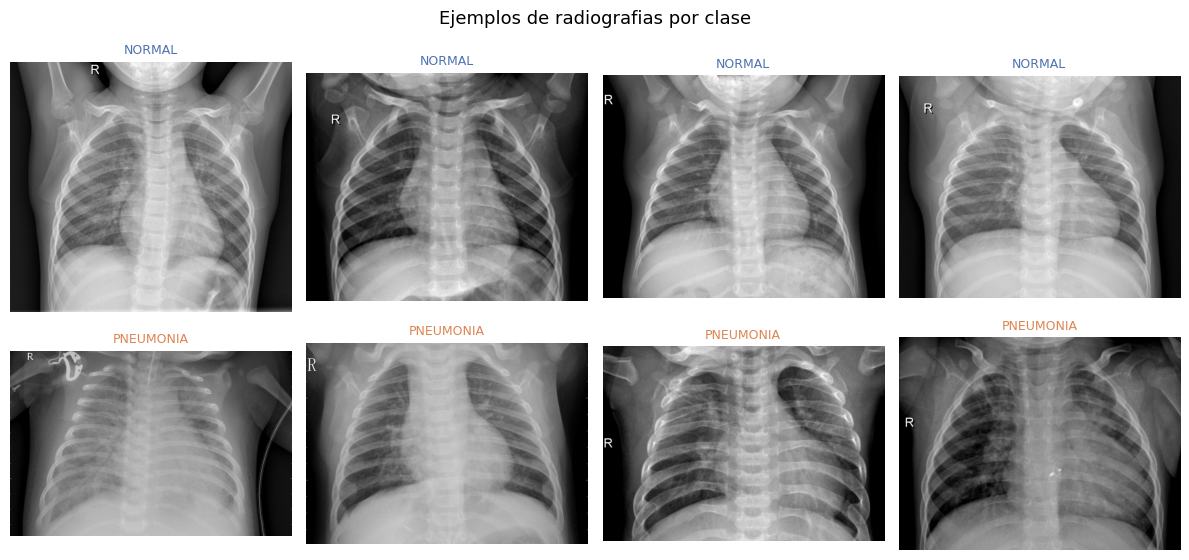

In [7]:
def obtener_imagenes(directorio, clase, n=4):
    ruta = os.path.join(directorio, clase)
    archivos = sorted([f for f in os.listdir(ruta)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[:n]
    imagenes = []
    for f in archivos:
        with Image.open(os.path.join(ruta, f)) as img:
            imagenes.append(np.array(img.convert('RGB')))
    return imagenes

normales    = obtener_imagenes(TRAIN_DIR, 'NORMAL',    n=4)
neumonias   = obtener_imagenes(TRAIN_DIR, 'PNEUMONIA', n=4)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for j, img in enumerate(normales):
    axes[0, j].imshow(img, cmap='gray')
    axes[0, j].set_title("NORMAL", fontsize=9, color='#4C72B0')
    axes[0, j].axis('off')

for j, img in enumerate(neumonias):
    axes[1, j].imshow(img, cmap='gray')
    axes[1, j].set_title("PNEUMONIA", fontsize=9, color='#DD8452')
    axes[1, j].axis('off')

plt.suptitle("Ejemplos de radiografias por clase", fontsize=13)
plt.tight_layout()
plt.savefig("eda_ejemplos.png", bbox_inches='tight', dpi=100)
plt.show()


### 1.4 Preprocesamiento necesario

Para alimentar los modelos de forma consistente se aplican los siguientes pasos:

1. **Redimensionamiento** a 150 x 150 píxeles: las imágenes originales tienen dimensiones variables.
2. **Normalización** de píxeles al rango [0, 1] dividiendo por 255: esto facilita la convergencia del gradiente.
3. **Escala de grises convertida a RGB**: se mantienen los 3 canales tal como los carga Keras, sin perjudicar la red.
4. **Data augmentation** (solo en train): rotaciones leves, flip horizontal y zoom para reducir el sobreajuste dado el tamaño moderado del conjunto.

La carpeta `val` original tiene muy pocas imágenes (16 por clase). Para el entrenamiento se
usa ese directorio como validación directa; el conjunto `test` se reserva exclusivamente para
la evaluación final de cada modelo.


In [8]:
IMG_SIZE  = (150, 150)
BATCH     = 32
CHANNELS  = 3

# Generador de entrenamiento: con augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1
)

# Generadores de validacion y test: solo normalización
eval_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=False
)

print("Clases detectadas:", train_gen.class_indices)
print(f"Batches en train: {len(train_gen)}")
print(f"Batches en val:   {len(val_gen)}")
print(f"Batches en test:  {len(test_gen)}")


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Clases detectadas: {'NORMAL': 0, 'PNEUMONIA': 1}
Batches en train: 163
Batches en val:   1
Batches en test:  20


---
## 2. Modelo Base (Sin Capas Convolucionales)

Antes de diseñar una CNN, se establece un punto de referencia usando una red densa simple.  
Esta red recibe la imagen **aplanada** como un vector de píxeles, sin ninguna operación espacial.

### Arquitectura

La red toma cada imagen de 150 × 150 × 3 = **67,500 valores de entrada** y los pasa por
dos capas densas antes de la capa de salida.

```
Entrada: 150 x 150 x 3
  -> Flatten  -> 67500 neuronas
  -> Dense(128, relu)
  -> Dropout(0.4)
  -> Dense(64, relu)
  -> Dense(1, sigmoid)   <- prediccion binaria
```


In [9]:
modelo_base = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
], name='modelo_base')

modelo_base.summary()


Model: "modelo_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,648,449 (32.99 MB)

 Trainable params: 8,648,449 (32.99 MB)

 Non-trainable params: 0 (0.00 B)

### Compilación y entrenamiento

Se usa el optimizador Adam con su tasa de aprendizaje por defecto (0.001),
y `binary_crossentropy` como función de pérdida dado que el problema es de clasificación binaria.

Se aplica `EarlyStopping` para detener el entrenamiento si la pérdida de validación
no mejora durante 5 épocas consecutivas, evitando sobreajuste y ahorrando tiempo de cómputo.


In [10]:
modelo_base.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Entrenando modelo base...")
historia_base = modelo_base.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)


Entrenando modelo base...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 344ms/step - accuracy: 0.7488 - loss: 1.5054 - val_accuracy: 0.7500 - val_loss: 0.5259
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 287ms/step - accuracy: 0.7577 - loss: 0.5389 - val_accuracy: 0.5000 - val_loss: 0.8393
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 416ms/step - accuracy: 0.7429 - loss: 0.5305 - val_accuracy: 0.5000 - val_loss: 0.7409
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 345ms/step - accuracy: 0.7429 - loss: 0.4882 - val_accuracy: 0.5000 - val_loss: 0.7311
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 312ms/step - accuracy: 0.7429 - loss: 0.4652 - val_accuracy: 0.5000 - val_loss: 0.6590
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 370ms/step - accuracy: 0.7429 - loss: 0.4761 - val_accuracy: 0.5000 - val_loss: 0.7135


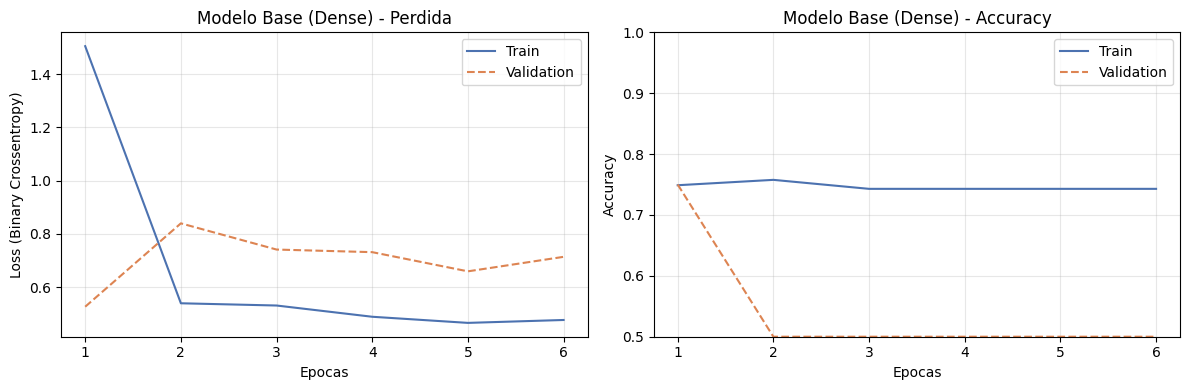

In [11]:
def graficar_historia(historia, titulo, nombre_archivo):
    epocas = range(1, len(historia.history['loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(epocas, historia.history['loss'],     label='Train',      color='#4C72B0')
    axes[0].plot(epocas, historia.history['val_loss'], label='Validation', color='#DD8452', linestyle='--')
    axes[0].set_title(f"{titulo} - Perdida")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Loss (Binary Crossentropy)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epocas, historia.history['accuracy'],     label='Train',      color='#4C72B0')
    axes[1].plot(epocas, historia.history['val_accuracy'], label='Validation', color='#DD8452', linestyle='--')
    axes[1].set_title(f"{titulo} - Accuracy")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(nombre_archivo, bbox_inches='tight', dpi=100)
    plt.show()

graficar_historia(historia_base, "Modelo Base (Dense)", "curvas_base.png")


In [12]:
loss_base, acc_base = modelo_base.evaluate(test_gen, verbose=0)
print(f"Modelo Base - Evaluacion en Test")
print(f"  Loss:     {loss_base:.4f}")
print(f"  Accuracy: {acc_base:.4f}  ({acc_base*100:.1f}%)")


Modelo Base - Evaluacion en Test
  Loss:     0.3896
  Accuracy: 0.8205  (82.1%)


---
## 3. Diseño de la Arquitectura Convolucional

### Justificación del diseño

Se diseña una CNN con **3 bloques convolucionales** seguidos de un clasificador denso.
Cada decisión de arquitectura está motivada por las características del problema:

| Componente | Elección | Razonamiento |
|---|---|---|
| Capas Conv2D | 3 bloques | Jerarquía: bordes -> texturas -> patrones pulmonares |
| Kernel size | 3×3 | El más común y eficiente; captura vecindades locales con poco costo |
| Stride | 1 | Conserva resolución espacial; la reducción se delega al pooling |
| Padding | 'same' | Evita reducción de dimensiones en la convolución misma |
| Activación | ReLU | Eficiente y efectiva; evita el problema de gradiente desvaneciente |
| Pooling | MaxPooling 2×2 | Reduce dimensiones a la mitad; selecciona la activación más fuerte |
| Filtros | 32 -> 64 -> 128 | Aumentar filtros conforme se reduce resolución es práctica estándar |
| BatchNorm | Sí | Estabiliza el entrenamiento y actúa como regularizador leve |
| Dropout | 0.5 (clasificador) | Regularización en la parte densa donde el sobreajuste es más probable |

### Diagrama de flujo

```
Entrada: 150 x 150 x 3
  Bloque 1: Conv2D(32, 3x3, same) -> BatchNorm -> ReLU -> MaxPool(2x2)  => 75 x 75 x 32
  Bloque 2: Conv2D(64, 3x3, same) -> BatchNorm -> ReLU -> MaxPool(2x2)  => 37 x 37 x 64
  Bloque 3: Conv2D(128, 3x3, same) -> BatchNorm -> ReLU -> MaxPool(2x2) => 18 x 18 x 128
  Flatten  => 41472
  Dense(256, relu) -> Dropout(0.5) -> Dense(1, sigmoid)
```


In [13]:
def construir_cnn(n_filtros=(32, 64, 128), n_capas=3, nombre='cnn_base'):
    """
    Construye una CNN configurable.
    
    Parametros
    ----------
    n_filtros : tuple
        Cantidad de filtros por bloque convolucional.
    n_capas : int
        Numero de bloques convolucionales a usar (1, 2 o 3).
    nombre : str
        Nombre del modelo.
    """
    modelo = Sequential(name=nombre)
    
    filtros_a_usar = n_filtros[:n_capas]
    
    for i, filtros in enumerate(filtros_a_usar):
        if i == 0:
            modelo.add(Conv2D(filtros, (3, 3), padding='same',
                              activation='relu', input_shape=(150, 150, 3)))
        else:
            modelo.add(Conv2D(filtros, (3, 3), padding='same', activation='relu'))
        
        modelo.add(BatchNormalization())
        modelo.add(MaxPooling2D(pool_size=(2, 2)))
    
    modelo.add(Flatten())
    modelo.add(Dense(256, activation='relu'))
    modelo.add(Dropout(0.5))
    modelo.add(Dense(1, activation='sigmoid'))
    
    return modelo

# CNN principal (3 bloques)
cnn_principal = construir_cnn(n_filtros=(32, 64, 128), n_capas=3, nombre='cnn_3bloques')
cnn_principal.summary()


Model: "cnn_3bloques"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,711,489 (40.86 MB)

 Trainable params: 10,711,041 (40.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
cnn_principal.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Entrenando CNN principal (3 bloques)...")
historia_cnn = cnn_principal.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop_cnn],
    verbose=1
)


Entrenando CNN principal (3 bloques)...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 614ms/step - accuracy: 0.8949 - loss: 0.9058 - val_accuracy: 0.5000 - val_loss: 55.7687
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 670ms/step - accuracy: 0.9250 - loss: 0.2160 - val_accuracy: 0.5000 - val_loss: 43.7782
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 665ms/step - accuracy: 0.9392 - loss: 0.1743 - val_accuracy: 0.5000 - val_loss: 10.0048
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9333 - loss: 0.1665 - val_accuracy: 0.5625 - val_loss: 2.5804
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 567ms/step - accuracy: 0.9484 - loss: 0.1437 - val_accuracy: 0.7500 - val_loss: 0.4891
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 546ms/step - accuracy: 0.9536 - loss: 0.1320 - val_accuracy: 0.9375 - val_loss: 0.2485
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.9526 - loss: 0.1406 - val_accuracy: 0.8125 - val_loss: 0.3947
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━

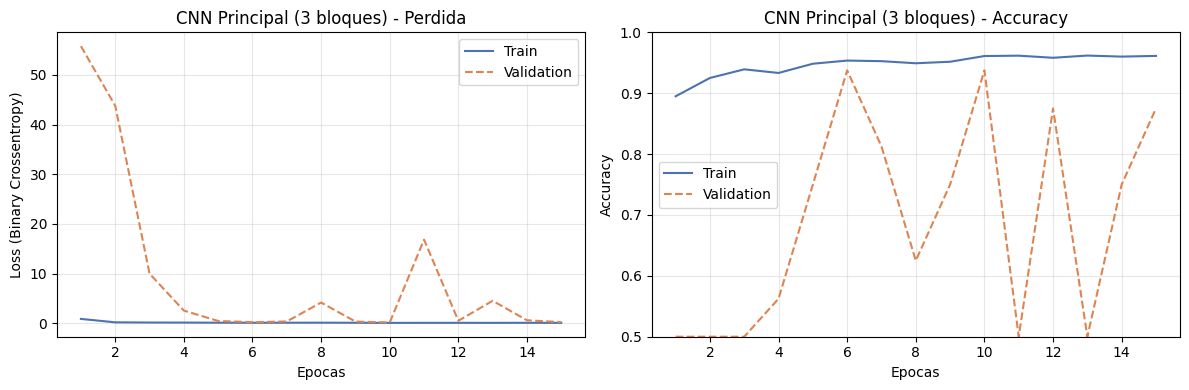

CNN Principal - Evaluacion en Test
  Loss:     0.3731
  Accuracy: 0.8958  (89.6%)


In [15]:
graficar_historia(historia_cnn, "CNN Principal (3 bloques)", "curvas_cnn_principal.png")

loss_cnn, acc_cnn = cnn_principal.evaluate(test_gen, verbose=0)
print(f"CNN Principal - Evaluacion en Test")
print(f"  Loss:     {loss_cnn:.4f}")
print(f"  Accuracy: {acc_cnn:.4f}  ({acc_cnn*100:.1f}%)")


In [16]:
    print("Entrenando CNN con 1 bloque...")
    cnn_1 = construir_cnn(n_filtros=(32,), n_capas=1, nombre='cnn_1bloque')
    cnn_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    h1 = cnn_1.fit(train_gen, epochs=20, validation_data=val_gen,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
                    verbose=0)
    loss1, acc1 = cnn_1.evaluate(test_gen, verbose=0)
    print(f"  CNN-1 -> Test Accuracy: {acc1:.4f}")

    print("Entrenando CNN con 2 bloques...")
    cnn_2 = construir_cnn(n_filtros=(32, 64), n_capas=2, nombre='cnn_2bloques')
    cnn_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    h2 = cnn_2.fit(train_gen, epochs=20, validation_data=val_gen,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
                    verbose=0)
    loss2, acc2 = cnn_2.evaluate(test_gen, verbose=0)
    print(f"  CNN-2 -> Test Accuracy: {acc2:.4f}")

    # CNN-3 ya fue entrenada
    loss3, acc3 = loss_cnn, acc_cnn
    print(f"  CNN-3 -> Test Accuracy: {acc3:.4f}  (ya entrenada)")


Entrenando CNN con 1 bloque...
  CNN-1 -> Test Accuracy: 0.8798
Entrenando CNN con 2 bloques...
  CNN-2 -> Test Accuracy: 0.8494
  CNN-3 -> Test Accuracy: 0.8958  (ya entrenada)


In [17]:
# Tabla comparativa
print("=" * 60)
print(f"{'Modelo':<15} {'Bloques':>8} {'Test Loss':>12} {'Test Acc':>10}")
print("-" * 60)
print(f"{'CNN-1':<15} {'1':>8} {loss1:>12.4f} {acc1:>10.4f}")
print(f"{'CNN-2':<15} {'2':>8} {loss2:>12.4f} x {acc2:>10.4f}")
print(f"{'CNN-3':<15} {'3':>8} {loss3:>12.4f} {acc3:>10.4f}")
print(f"{'Modelo Base':<15} {'0 (dense)':>8} {loss_base:>12.4f} {acc_base:>10.4f}")
print("=" * 60)


Modelo           Bloques    Test Loss   Test Acc
------------------------------------------------------------
CNN-1                  1       0.4607     0.8798
CNN-2                  2       0.5661 x     0.8494
CNN-3                  3       0.3731     0.8958
Modelo Base     0 (dense)       0.3896     0.8205


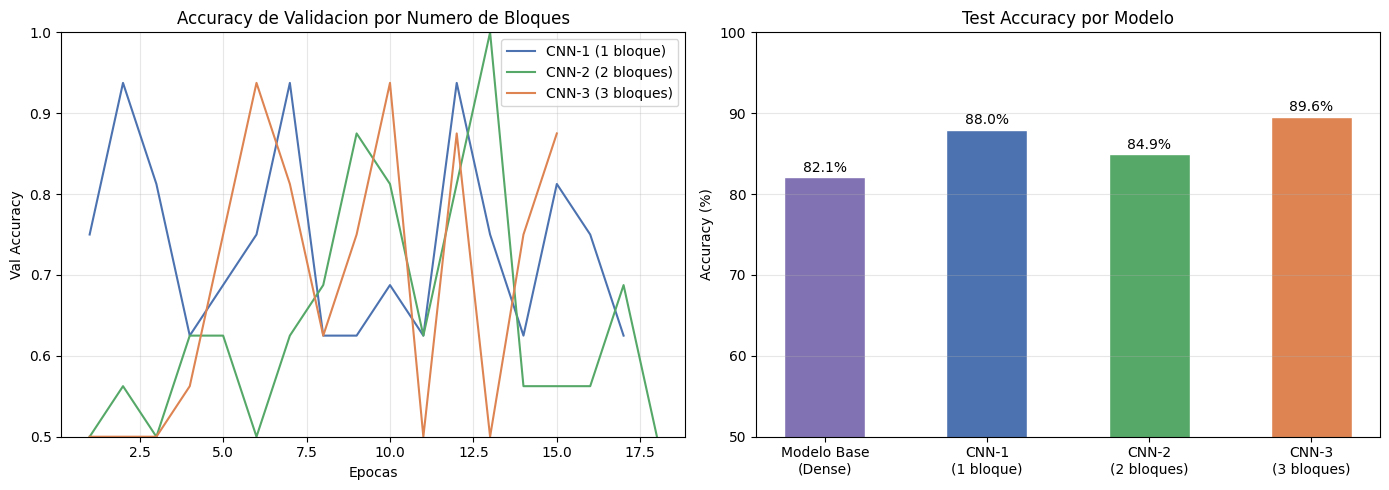

In [19]:
# Grafica de curvas de aprendizaje de los tres experimentos
epocas_1 = range(1, len(h1.history['val_accuracy']) + 1)
epocas_2 = range(1, len(h2.history['val_accuracy']) + 1)
epocas_3 = range(1, len(historia_cnn.history['val_accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val accuracy
axes[0].plot(epocas_1, h1.history['val_accuracy'], label='CNN-1 (1 bloque)', color='#4C72B0')
axes[0].plot(epocas_2, h2.history['val_accuracy'], label='CNN-2 (2 bloques)', color='#55A868')
axes[0].plot(epocas_3, historia_cnn.history['val_accuracy'], label='CNN-3 (3 bloques)', color='#DD8452')
axes[0].set_title("Accuracy de Validacion por Numero de Bloques")
axes[0].set_xlabel("Epocas")
axes[0].set_ylabel("Val Accuracy")
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(True, alpha=0.3)

# Barras de test accuracy
modelos_exp = ['Modelo Base\n(Dense)', 'CNN-1\n(1 bloque)', 'CNN-2\n(2 bloques)', 'CNN-3\n(3 bloques)']
accs_exp    = [acc_base, acc1, acc2, acc3]
colores_exp = ['#8172B3', '#4C72B0', '#55A868', '#DD8452']

bars = axes[1].bar(modelos_exp, [a * 100 for a in accs_exp],
                    color=colores_exp, edgecolor='white', width=0.5)
axes[1].set_title("Test Accuracy por Modelo")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(50, 100)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accs_exp):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.3,
                  f"{acc*100:.1f}%",
                  ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("experimento_profundidad.png", bbox_inches='tight', dpi=100)
plt.show()
